#  MuJoCo Bootcamp : 2D Hopper

---- 

- conda env : [ai_robotics](../../../README.md#setup-a-conda-environment)

---


### Reference : 
- https://pab47.github.io/mujoco.html
- https://youtu.be/ve7AnF6bzdE

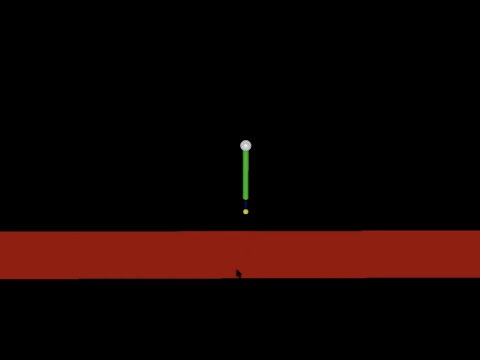

In [1]:
from IPython.display import YouTubeVideo

YouTubeVideo('ve7AnF6bzdE')

## Run python code

In [ ]:
!python hopper.py 

## Jupyter code

### Load XML file and build model and data

In [1]:
import mujoco as mj
import numpy as np
import mediapy as media
from numpy.linalg import inv
from scipy.linalg import solve_continuous_are
import os

# Create an XML file string for a simple ball on a plane
xml_path = "./hopper.xml" 

# MuJoCo data structures
model = mj.MjModel.from_xml_path(xml_path)
data = mj.MjData(model)

### Setup the controller

In [2]:
step_no = 0

FSM_AIR1 = 0
FSM_STANCE1 = 1
FSM_STANCE2 = 2
FSM_AIR2 = 3

fsm = FSM_AIR1

def controller(model, data):
    """
    This function implements a controller that
    mimics the forces of a fixed joint before release
    """
    global fsm
    global step_no

    body_no = 3
    z_foot = data.xpos[body_no, 2]
    vz_torso = data.qvel[1]

    # Lands on the ground
    if fsm == FSM_AIR1 and z_foot < 0.05:
        fsm = FSM_STANCE1

    # Moving upward
    if fsm == FSM_STANCE1 and vz_torso > 0.0:
        fsm = FSM_STANCE2

    # Take off
    if fsm == FSM_STANCE2 and z_foot > 0.05:
        fsm = FSM_AIR2

    # Moving downward
    if fsm == FSM_AIR2 and vz_torso < 0.0:
        fsm = FSM_AIR1
        step_no += 1

    if fsm == FSM_AIR1:
        set_position_servo(2, 100)
        set_velocity_servo(3, 10)

    if fsm == FSM_STANCE1:
        set_position_servo(2, 1000)
        set_velocity_servo(3, 0)

    if fsm == FSM_STANCE2:
        set_position_servo(2, 1000)
        set_velocity_servo(3, 0)
        data.ctrl[0] = -0.2

    if fsm == FSM_AIR2:
        set_position_servo(2, 100)
        set_velocity_servo(3, 10)
        data.ctrl[0] = 0.0

def init_controller(model,data):
    # pservo-hip
    set_position_servo(0, 100)

    # vservo-hip
    set_velocity_servo(1, 10)

    # pservo-knee
    set_position_servo(2, 1000)

    # vservo-knee
    set_velocity_servo(3, 0)

def set_position_servo(actuator_no, kp):
    model.actuator_gainprm[actuator_no, 0] = kp
    model.actuator_biasprm[actuator_no, 1] = -kp

def set_velocity_servo(actuator_no, kv):
    model.actuator_gainprm[actuator_no, 0] = kv
    model.actuator_biasprm[actuator_no, 2] = -kv

# init_controller(model,data)
mj.set_mjcb_control(controller)

### Setup the configuration of render

In [3]:
# Offscreen rendering setup
width, height = 200, 200
renderer = mj.Renderer(model, width, height)

# Set camera configuration
cam = mj.MjvCamera()                        # Abstract camera
opt = mj.MjvOption()                        # visualization options
mj.mjv_defaultCamera(cam)
mj.mjv_defaultOption(opt)
# Set camera configuration
cam.azimuth = 89.608063
cam.elevation = -11.588379
cam.distance = 5.0
cam.lookat = np.array([0.0, 0.0, 1.5])

### Initialization 

In [4]:
# # Set initial configuration
# data.qpos[2] = -np.pi/2
# data.qpos[5] = -np.pi/2



### Simulation

In [5]:
# Store frames for visualization
frames = []
framerate = 30
simend = 3
simstart = data.time
mj.mj_resetData(model, data)
init_controller(model,data)

while data.time < simend:
    simstart = data.time
    while (data.time - simstart < 1.0/60.0):
        mj.mj_step(model, data)
    
    # Render the scene from the specified camera
    renderer.update_scene(data, camera=cam)
    
    # Get the rendered RGB image and store it
    rgb_image = renderer.render()
    frames.append(rgb_image)

media.show_video(frames, fps=framerate)




This browser does not support the video tag.
